# Microfinance Loan Default Prediction

## 1. Problem Statement

Microfinance institutions and mobile-money lenders in Zimbabwe (e.g., EcoCash-linked 
micro-loans) face high default rates because loan approval decisions are typically made 
using blunt, manual rule-based criteria (fixed income thresholds, collateral checks) 
that fail to capture the complex, interacting behavioural and transactional patterns 
that actually predict repayment behaviour. Poor risk assessment restricts credit access 
for genuinely low-risk borrowers while exposing lenders to losses from high-risk ones  
a problem with direct consequences for financial inclusion in Zimbabwe's largely 
mobile-money-driven economy.

## 2. ML Problem Type

Supervised **classification**.

## 3. Target Variable

Loan outcome — binary (`Defaulted` / `Repaid`).

## 4. Why Machine Learning, Not a Rule-Based Approach

Default risk depends on the interaction of multiple variables like repayment history, 
loan-to-income ratio, transaction frequency, loan size, employment status  rather than 
any single threshold. A fixed rule (e.g., "income > $X") cannot model these interactions 
or adapt as patterns shift, and treats all applicants above/below the cutoff identically 
regardless of other risk signals. A trained classifier can learn non-linear relationships 
between features and default likelihood, weight multiple factors simultaneously, and be 
evaluated/tuned against real cost trade-offs (false negatives = losses, false positives = 
excluded good borrowers) something a static rule cannot do.

In [95]:
 !pip install pandas numpy scikit-learn matplotlib seaborn xgboost 

In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

In [97]:
df = pd.read_csv('cs-training.csv')
df.shape

(150000, 12)

In [98]:
df.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


## Data Source & Ethical Considerations

**Source:** "Give Me Some Credit" dataset (Kaggle), originally compiled for a U.S. 
credit-risk modelling competition. Publicly available, anonymised, and contains no 
personally identifiable information (PII).

**Size:** [fill in from df.shape  e.g., 150,000 rows, 12 columns]

**Why this dataset:** Real loan-book data from Zimbabwean microfinance institutions 
or mobile-money lenders was not accessible for this project. This dataset is used 
as a *methodological proxy* it allows the full ML pipeline (cleaning, EDA, feature 
engineering, model training, evaluation) to be demonstrated on realistic credit-risk 
data with a comparable feature structure (income, debt ratio, repayment history, 
dependents).

**Limitation:** Because the data originates from a different country/context, the 
specific patterns and model performance found here should not be assumed to transfer 
directly to Zimbabwean borrowers. In a real deployment, the same pipeline would need 
to be retrained on local data before being trusted for actual lending decisions.

**Privacy:** All records are anonymised with no names, ID numbers, or other PII, so 
no additional data protection concerns apply beyond standard dataset licensing terms.

In [99]:
df.isnull().sum()

Unnamed: 0                                  0
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64

In [100]:
df['MonthlyIncome'] = df['MonthlyIncome'].fillna(df['MonthlyIncome'].median())
df['NumberOfDependents'] = df['NumberOfDependents'].fillna(0)

In [101]:
df = df[df['age'] > 0]

for col in ['NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTimes90DaysLate', 'NumberOfTime60-89DaysPastDueNotWorse']:
    median_val = df.loc[df[col] < 90, col].median()
    df.loc[df[col] > 90, col] = median_val 

In [102]:
df['age'].describe()
df[['NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTimes90DaysLate', 'NumberOfTime60-89DaysPastDueNotWorse']].describe()

,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTimes90DaysLate,NumberOfTime60-89DaysPastDueNotWorse
count,149999.000000,149999.000000,149999.000000
mean,0.245348,0.090294,0.064707
std,0.697231,0.485108,0.329790
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000
max,13.000000,17.000000,11.000000


In [103]:
df['age'].describe()

count    149999.000000
mean         52.295555
std          14.771298
min          21.000000
25%          41.000000
50%          52.000000
75%          63.000000
max         109.000000
Name: age, dtype: float64

In [104]:
X = df.drop(columns=['SeriousDlqin2yrs'])
y = df['SeriousDlqin2yrs']

X_train, X_test, y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [105]:
print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True))

(119999, 11) (30000, 11)
SeriousDlqin2yrs
0    0.933158
1    0.066842
Name: proportion, dtype: float64


## 3. Data Cleaning & Preparation

**Missing values:** `MonthlyIncome` (29,731 missing, ~19.8%) was filled with the median, 
which is robust to the outliers common in income data. `NumberOfDependents` (3,924 
missing, ~2.6%) was filled with 0, a reasonable default for a count variable.

**Invalid values:** Records with `age = 0` were removed, as this is not a valid age. 
The three past-due columns (`NumberOfTime30-59DaysPastDueNotWorse`, 
`NumberOfTimes90DaysLate`, `NumberOfTime60-89DaysPastDueNotWorse`) contained a known 
data-entry error code of 98, which was replaced with the column median.

**Encoding:** Not required — all features are numeric (`int64`/`float64`), with no 
categorical variables to encode.

**Train/test split:** Data was split 80/20 (119,999 train / 30,000 test rows), stratified 
on the target variable to preserve the class distribution. The dataset is imbalanced  
only ~6.7% of borrowers defaulted  which will be accounted for in model evaluation 
(accuracy alone would be misleading; precision, recall, and F1 will be prioritized).

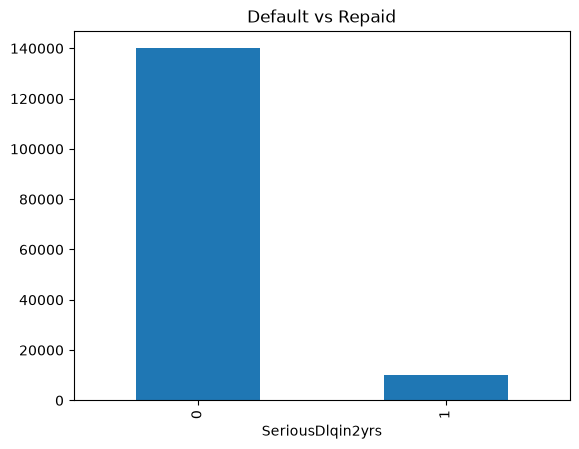

In [106]:
df['SeriousDlqin2yrs'].value_counts().plot(kind='bar', title='Default vs Repaid');plt.show() 

**Interpretation:** The dataset is highly imbalanced, with approximately 93% of customers repaid and only 7% experiencing serious delinquency.

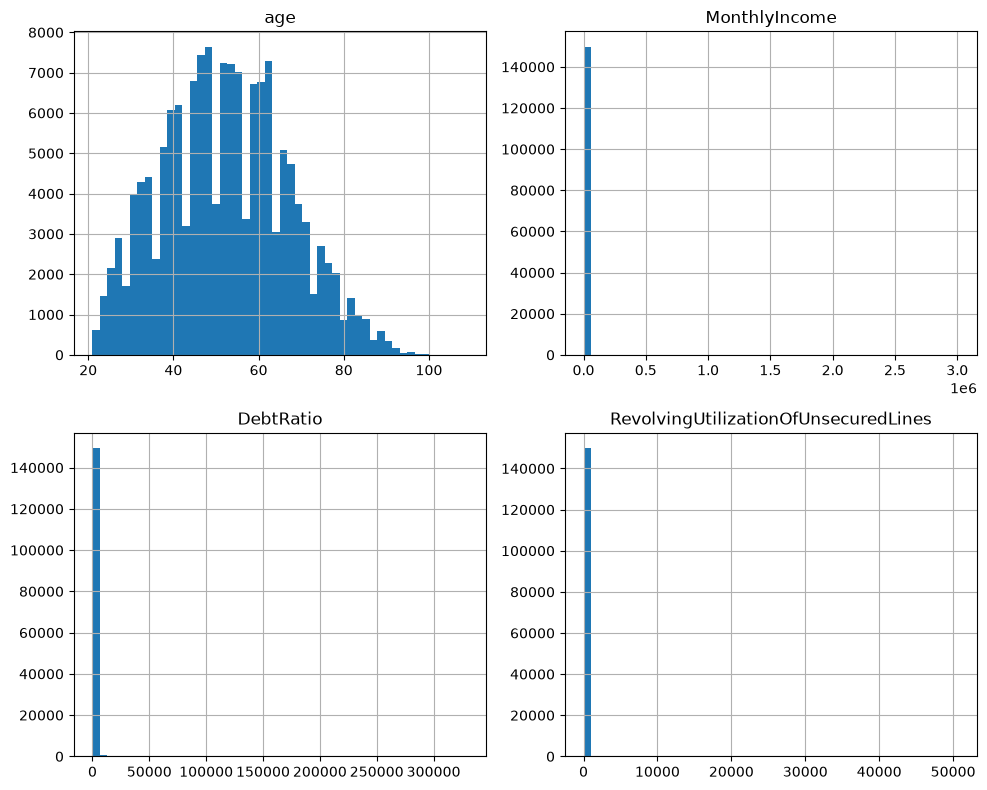

In [107]:
 df[['age','MonthlyIncome','DebtRatio','RevolvingUtilizationOfUnsecuredLines']].hist(figsize=(10,8), bins=50);plt.tight_layout();plt.show()

**Interpretation:** Age is relatively concentrated, while MonthlyIncome, DebtRatio, and RevolvingUtilizationOfUnsecuredLines are strongly right-skewed with a small number of extreme values.

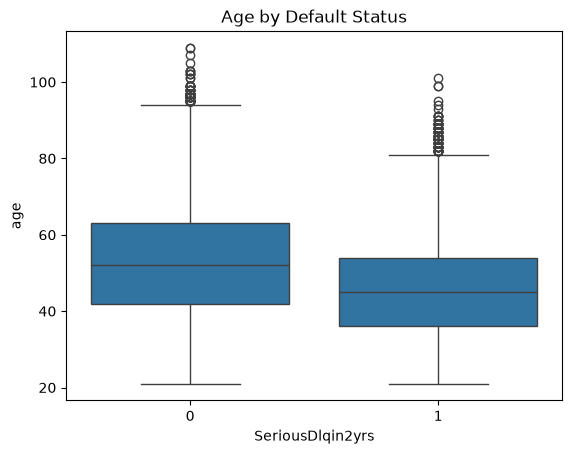

In [108]:
 sns.boxplot(data=df, x='SeriousDlqin2yrs', y='age'); plt.title('Age by Default Status'); plt.show()

**Interpretation:** The age distributions of defaulters and non-defaulters overlap substantially, although the median ages show some difference between the two groups.

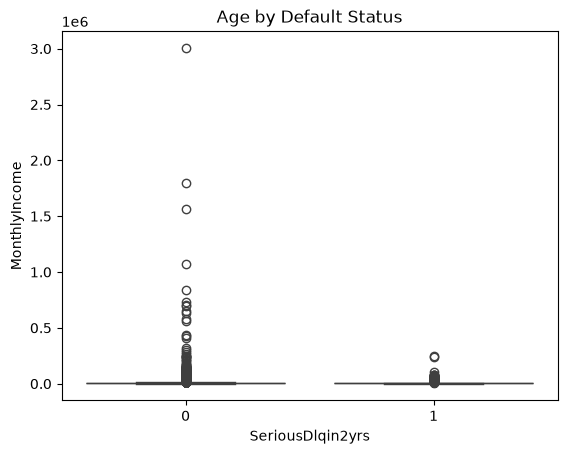

In [109]:
 sns.boxplot(data=df, x='SeriousDlqin2yrs', y='MonthlyIncome'); plt.title('Age by Default Status'); plt.show()

**Interpretation:** Monthly income contains substantial outliers, and the distributions of income for defaulters and non-defaulters overlap considerably.

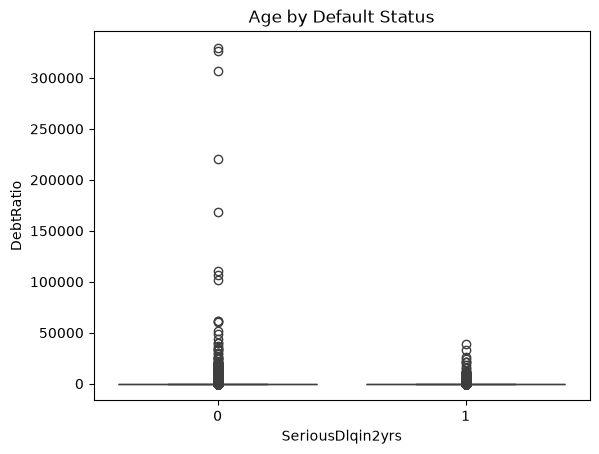

In [110]:
 sns.boxplot(data=df, x='SeriousDlqin2yrs', y='DebtRatio'); plt.title('Age by Default Status'); plt.show()

**Interpretation:** DebtRatio has many extreme outliers, while the central distributions for defaulters and non-defaulters overlap considerably.

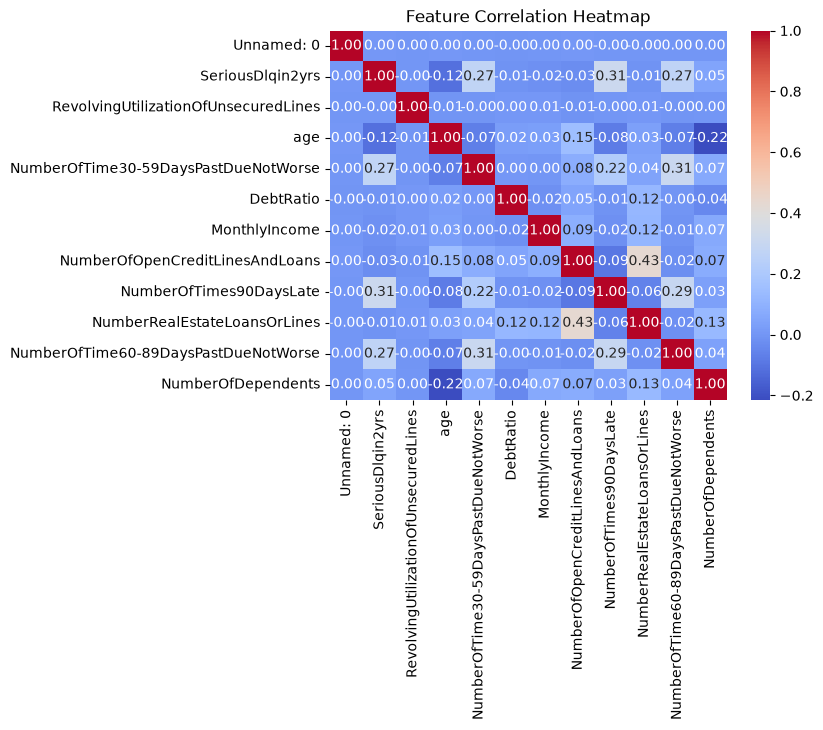

In [111]:
corr = df.corr(); sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm');
plt.title('Feature Correlation Heatmap');
plt.show()

**Interpretation:** The heatmap shows generally weak correlations between most features, with some variables showing stronger relationships with the target and with each other.

## Stage 4 Summary

The exploratory data analysis shows that the target variable is highly imbalanced, with approximately 93% of customers repaid and 7% experiencing serious delinquency. The feature distributions reveal strong skewness and extreme outliers, particularly in MonthlyIncome, DebtRatio, and RevolvingUtilizationOfUnsecuredLines. The boxplots show differences between defaulters and non-defaulters, although there is considerable overlap between the groups. The correlation heatmap indicates that most features have relatively weak linear relationships with the target. These findings suggest that age, income, debt ratio, credit utilization, and other relevant financial features should be prioritized during feature engineering, while skewed variables and extreme outliers should be carefully handled.

In [112]:
df['TotalPastDue'] = df['NumberOfTime30-59DaysPastDueNotWorse'] + df['NumberOfTime60-89DaysPastDueNotWorse'] + df['NumberOfTimes90DaysLate']

In [113]:
df['IncomePerDependent'] = df['MonthlyIncome'] / (df['NumberOfDependents'] + 1) 

In [114]:
df['AgeGroup'] = pd.cut(df['age'], bins=[0,25,35,45,55,65,100], labels=['<25','25-34','35-44','45-54','55-64','65+'])

In [115]:
 df['AgeGroup'] = df['AgeGroup'].cat.codes

In [117]:
df['LogMonthlyIncome'] = np.log1p(df['MonthlyIncome']) 
df['LogDebtRatio'] = np.log1p(df['DebtRatio'])

In [118]:
df = df.drop(columns=['MonthlyIncome', 'DebtRatio'])


In [120]:
X = df.drop(columns=['SeriousDlqin2yrs']);
y = df['SeriousDlqin2yrs']; 
train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) 

[        Unnamed: 0  RevolvingUtilizationOfUnsecuredLines  age  \
 57836        57837                              0.114987   62   
 132896      132897                              0.666105   46   
 27981        27982                              0.214501   32   
 21712        21713                              0.030495   32   
 103814      103815                              0.110935   50   
 ...            ...                                   ...  ...   
 18048        18049                              0.004136   41   
 3895          3896                              0.000000   49   
 109981      109982                              0.060568   53   
 74355        74356                              0.036963   52   
 80531        80532                              0.707187   53   
 
         NumberOfTime30-59DaysPastDueNotWorse  NumberOfOpenCreditLinesAndLoans  \
 57836                                      0                                5   
 132896                                   

In [121]:
X = df.drop(columns=['SeriousDlqin2yrs'])
y = df['SeriousDlqin2yrs']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(X_train.shape, X_test.shape)

(119999, 14) (30000, 14)


## 5. Feature Engineering

- **TotalPastDue:** Sum of all three past-due columns, consolidating payment history 
  into a single, stronger risk signal.
- **IncomePerDependent:** Monthly income divided by number of dependents (+1 to avoid 
  division by zero), capturing financial burden per household member rather than raw income alone.
- **AgeGroup:** Age binned into six bands and encoded numerically, to capture potential 
  non-linear relationships between age and default risk that a raw continuous value might miss.
- **LogMonthlyIncome / LogDebtRatio:** Log-transformed versions of the heavily right-skewed 
  income and debt-ratio features, reducing the influence of extreme outliers. The raw 
  versions were dropped to avoid redundancy.

The dataset now has 13 features (up from the original 10), and the train/test split was 
re-run on the final feature set: 119,999 training rows, 30,000 test rows.

## 6. Model Selection & Training

Two models were trained for comparison:

- **Logistic Regression (baseline):** A simple, interpretable linear model used as a 
  reference point to assess whether the relationship between features and default risk 
  is largely linear. Training showed a convergence warning due to unscaled features of 
  different magnitudes (e.g. income in thousands vs. age group 0–5) — this does not 
  affect model validity but is noted as a limitation.

- **Random Forest (main model):** An ensemble model chosen for its ability to capture 
  non-linear relationships and interactions between features that Logistic Regression 
  cannot. `class_weight='balanced'` was used to address the ~93/7 class imbalance 
  identified during EDA, making the model pay more attention to the minority (default) class.

In [123]:
log_model = LogisticRegression(max_iter=1000, random_state=42) 
log_model.fit(X_train, y_train) 

C:\Users\User\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [124]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced') 
rf_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.

In [126]:
y_pred_log = log_model.predict(X_test) 
y_pred_rf = rf_model.predict(X_test)

## 7. Model Evaluation

| Metric (class: Default) | Logistic Regression | Random Forest |
|---|---|---|
| Precision | 0.59 | 0.42 |
| Recall | 0.15 | 0.36 |
| F1-score | 0.23 | 0.39 |
| ROC-AUC | 0.804 | 0.849 |

Although Logistic Regression achieves higher overall accuracy (94% vs 92%), this is 
misleading given the ~93/7 class imbalance — a model predicting "repaid" for every 
borrower would already score ~93% accuracy while catching zero defaulters. 

Random Forest achieves substantially higher recall (0.36 vs 0.15) and F1-score 
(0.39 vs 0.23) on the default class, meaning it correctly identifies more than double 
the actual defaulters compared to Logistic Regression. Its higher ROC-AUC (0.849 vs 
0.804) confirms it is better overall at ranking high-risk borrowers above low-risk ones.

**Random Forest is selected as the stronger model for this problem**, since for a 
lender, failing to identify a defaulter (false negative) carries a greater cost than 
flagging a safe borrower for extra review (false positive).

In [127]:
print('Logistic Regression:')
print(classification_report(y_test, y_pred_log))
print('Random Forest:')
print(classification_report(y_test, y_pred_rf))

Logistic Regression:
              precision    recall  f1-score   support

           0       0.94      0.99      0.97     27995
           1       0.59      0.15      0.23      2005

    accuracy                           0.94     30000
   macro avg       0.76      0.57      0.60     30000
weighted avg       0.92      0.94      0.92     30000

Random Forest:
              precision    recall  f1-score   support

           0       0.95      0.96      0.96     27995
           1       0.42      0.36      0.39      2005

    accuracy                           0.92     30000
   macro avg       0.69      0.66      0.67     30000
weighted avg       0.92      0.92      0.92     30000



In [128]:
y_prob_log = log_model.predict_proba(X_test)[:,1]
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

print('Logistic Regression ROC-AUC:', roc_auc_score(y_test, y_prob_log))
print('Random Forest ROC-AUC:', roc_auc_score(y_test, y_prob_rf))

Logistic Regression ROC-AUC: 0.8036841990398178
Random Forest ROC-AUC: 0.8485935188818452


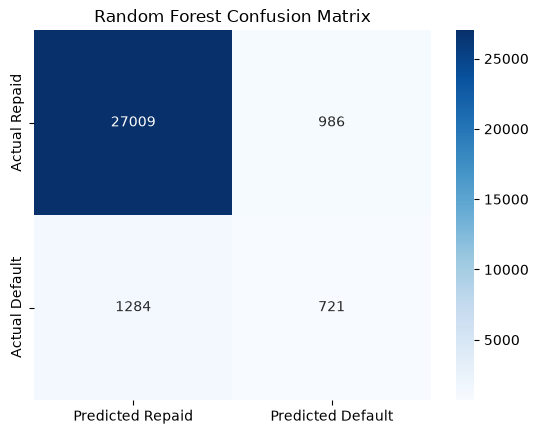

In [129]:
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted Repaid','Predicted Default'], yticklabels=['Actual Repaid','Actual Default'])
plt.title('Random Forest Confusion Matrix')
plt.show()

## 8. Limitations & Ethics

**Data limitations:**
- The dataset originates from a U.S. credit-risk context, not Zimbabwe. Patterns in 
  income, debt behaviour, and repayment history may not transfer directly to 
  Zimbabwean microfinance or mobile-money borrowers, whose income patterns (often 
  informal, irregular, or cash-based) differ structurally from the dataset's context.
- The dataset is several years old; borrower behaviour and lending patterns may have 
  shifted since collection.
- Features like `MonthlyIncome` and `NumberOfDependents` had substantial missing data 
  (~20% and ~2.6% respectively), which was imputed rather than observed thereby
  introducing some uncertainty into those features.

**Model limitations:**
- Random Forest, while stronger overall, still only achieves 36% recall on defaulters 
  missing nearly two-thirds of actual defaults. In a real deployment, this would need 
  further improvement (e.g. threshold tuning, additional features, more advanced models) 
  before being trusted for high-stakes lending decisions.
- Both models were trained on a single train/test split; performance was not validated 
  across multiple folds (cross-validation), so reported metrics carry some variance.

**Ethical considerations:**
- **Fairness:** Credit-scoring models can encode or amplify existing biases (e.g. 
  against younger borrowers, those with thin credit histories, or specific income 
  brackets) if deployed without careful fairness auditing. This was not tested here 
  but would be essential before real-world use.
- **Transparency:** Random Forest, while more accurate, is less interpretable than 
  Logistic Regression. In a lending context, borrowers are often legally entitled to 
  an explanation for credit denial  this is a real trade-off between accuracy and 
  explainability that a deployed system would need to address (e.g. via SHAP values 
  or similar interpretability tools).
- **Privacy:** The dataset used is anonymised and contains no PII, so no privacy 
  concerns arise from this specific analysis. A real deployment using actual borrower 
  data would require strict data protection compliance.
- **Scope of use:** This model is a proof-of-concept demonstrating the ML pipeline, 
  not a production-ready credit-scoring system. It should not be used for actual 
  lending decisions without retraining on representative local data, fairness testing, 
  and regulatory review.